# Librerias

In [1]:
import pandas as pd
pd.set_option("display.max_columns",30)
pd.set_option("display.max_rows",3000)
import matplotlib.pyplot as plt
import cufflinks as cf
cf.go_offline()
import numpy as np

### imputacion variables continuas
from sklearn.impute import SimpleImputer
from scipy.stats import ks_2samp

In [2]:
df = pd.read_csv("C:/Users/pablo/OneDrive/Documentos/FES/Minería/Práctica 4/ecobicidatos.csv")

C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\2437238250.py:1: DtypeWarning:

Columns (2,7,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.



# Analisis Exploratorio

### completitud de información

In [3]:
df.shape

(31687506, 13)

In [4]:
def completitud_datos_nulos(df):
    return df.isnull().sum().sort_values(ascending=False) / df.shape[0]

In [5]:
df.isnull().sum().sort_values(ascending=False) / df.shape[0]

Ciclo_EstacionArribo     9.875940e-01
Unnamed: 11              9.841267e-01
Unnamed: 9               9.634416e-01
Unnamed: 10              9.634416e-01
Ciclo_Estacion_Arribo    4.896441e-02
Fecha_Arribo             3.655838e-02
Hora_Arribo              1.587329e-02
Genero_Usuario           4.765222e-03
Bici                     5.996054e-07
Fecha_Retiro             5.364891e-07
Ciclo_Estacion_Retiro    5.364891e-07
Edad_Usuario             5.364891e-07
Hora_Retiro              5.364891e-07
dtype: float64

### definicion de variables

#### continuas

In [8]:
varc = [x for x in list(df.describe()) if x not in 'Unnamed: 9' + 'Ciclo_EstacionArribo']

In [9]:
varc

['Edad_Usuario', 'Ciclo_Estacion_Retiro', 'Ciclo_Estacion_Arribo']

##### Analasis univariado

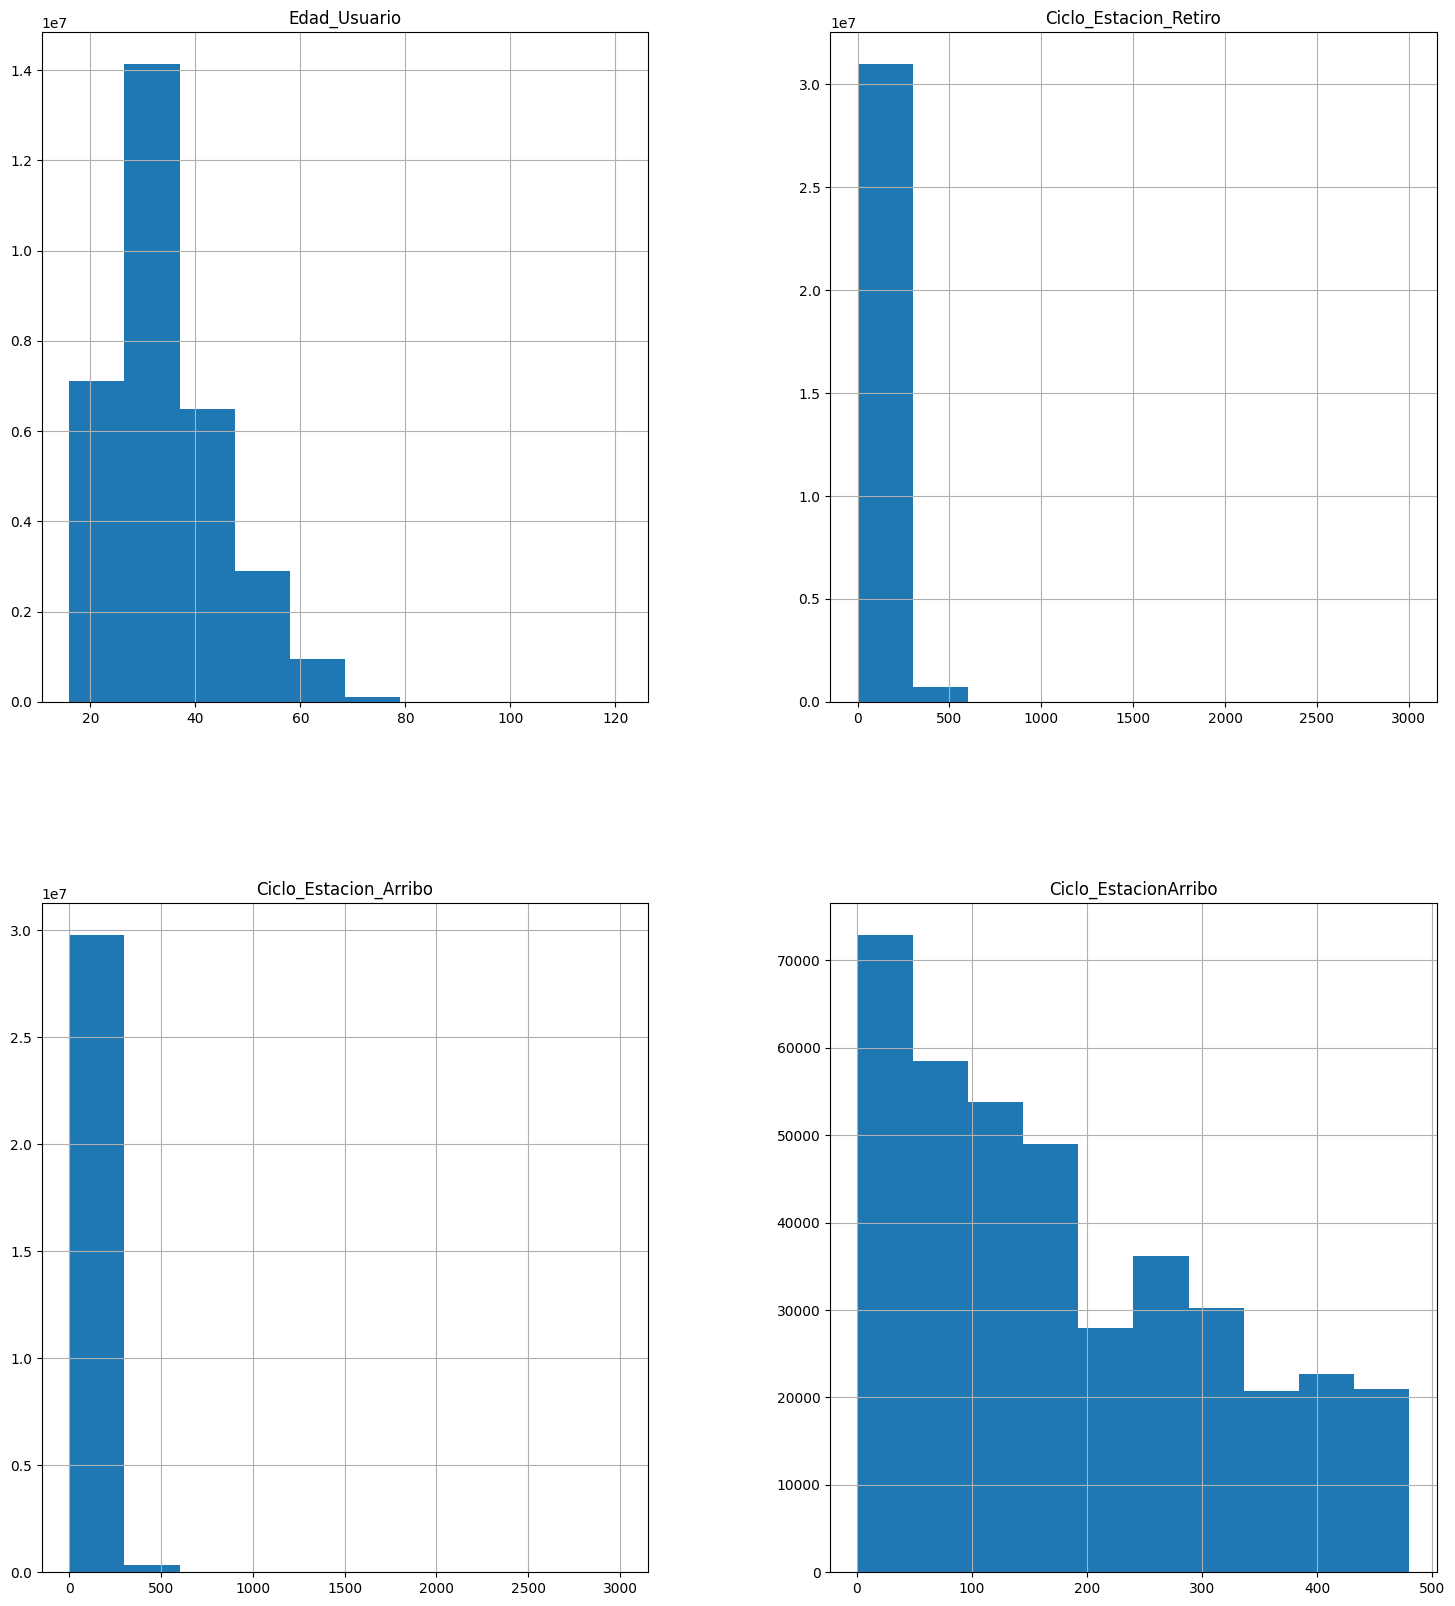

In [8]:
df[varc].hist(figsize=(18,20));

###  Eliminacion de valores extremos

In [10]:
percentiles = {}
for var in varc:
    perc1 = df[f"{var}"].describe([x/10 for x in range(10)] + [0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).to_frame().loc['90%',:]
    perc99 = df[f"{var}"].describe([x/10 for x in range(10)] + [0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).to_frame().loc['99%',:]
    minimo = df[f"{var}"].describe([x/10 for x in range(10)] + [0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).to_frame().loc['min',:]
    maximo = df[f"{var}"].describe([x/10 for x in range(10)] + [0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).to_frame().loc['max',:]

    izq = round(perc1[0],3)
    der = round(perc99[0],3)
    print(minimo[0])
    print(izq)
    print(der)
    print(maximo[0])
    outliersPerc = df[f"{var}"][~((df[f"{var}"]<=izq) | (df[f"{var}"]>=der))].to_frame()
    percentiles[f"{var}"] = (outliersPerc[var].shape[0])
    df[f"{var}"] = outliersPerc[var]

C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\3857946851.py:8: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\3857946851.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\3857946851.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\3857946851.py:13: FutureWarning:

Series.__get

16.0
50.0
64.0
121.0


C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\3857946851.py:8: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\3857946851.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\3857946851.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\3857946851.py:13: FutureWarning:

Series.__get

1.0
242.0
392.0
3002.0
1.0
237.0
320.0
3003.0


C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\3857946851.py:8: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\3857946851.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\3857946851.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\3857946851.py:13: FutureWarning:

Series.__get

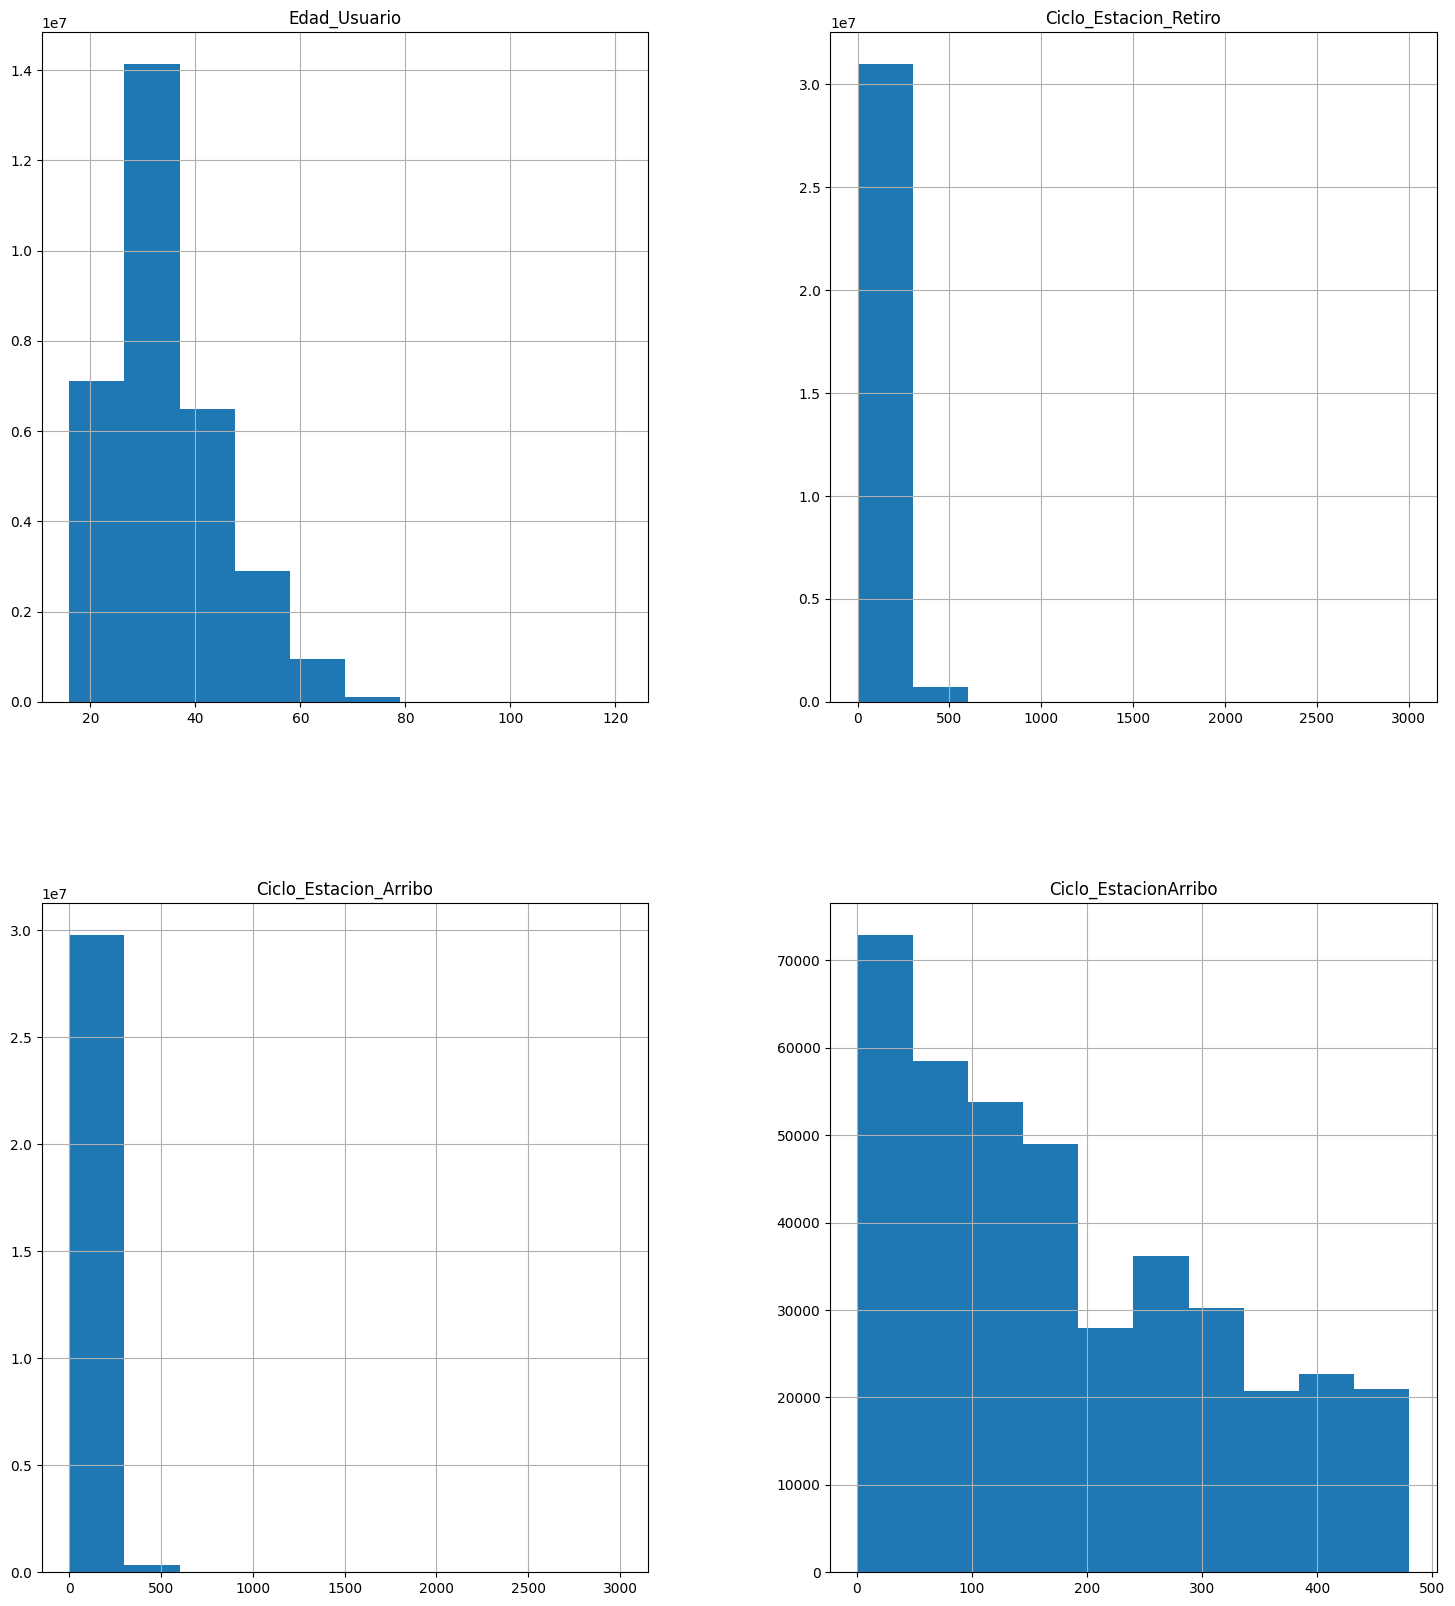

In [9]:
df[varc].hist(figsize=(18,20));

In [11]:
df.shape

(31687506, 13)

#### categoricas

In [13]:
vard = [y for y in df.columns if y not in varc + ['Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Ciclo_EstacionArribo']]

In [14]:
vard

['Genero_Usuario',
 'Bici',
 'Fecha_Retiro',
 'Hora_Retiro',
 'Fecha_Arribo',
 'Hora_Arribo']

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Leer solo una parte del CSV para no saturar la memoria
df = pd.read_csv('ecobicidatos.csv', nrows=100000)

# Paso 1: Codificar con LabelEncoder
le = LabelEncoder()
df['Genero_Usuario'] = le.fit_transform(df['Genero_Usuario'])

# Paso 2: Escalar de 0 a 1 con MinMaxScaler
scaler = MinMaxScaler()
df['Genero_Usuario'] = scaler.fit_transform(df[['Genero_Usuario']])

# Conversión de fechas al formato correcto 
df['Fecha_Retiro'] = pd.to_datetime(df['Fecha_Retiro'], dayfirst=True, errors='coerce')
df['Fecha_Arribo'] = pd.to_datetime(df['Fecha_Arribo'], dayfirst=True, errors='coerce')

# Eliminar filas con fechas inválidas
df = df[df['Fecha_Retiro'].notna() & df['Fecha_Arribo'].notna()]

# Convertir hora a decimal continuo 
def hora_a_decimal(hora_str):
    try:
        h, m = map(int, hora_str.split(':')[:2])
        return h + m / 60
    except:
        return None

df['Hora_Retiro'] = df['Hora_Retiro'].apply(hora_a_decimal)
df['Hora_Arribo'] = df['Hora_Arribo'].apply(hora_a_decimal)

# Eliminar filas con horas inválidas
df = df[df['Hora_Retiro'].notna() & df['Hora_Arribo'].notna()]

# Transformar fechas a día del año 
df['Fecha_Retiro'] = df['Fecha_Retiro'].dt.dayofyear
df['Fecha_Arribo'] = df['Fecha_Arribo'].dt.dayofyear


C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\4283715898.py:15: UserWarning:

Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.

C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\4283715898.py:16: UserWarning:

Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.



In [88]:
df

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_Estacion_Arribo,Fecha_Arribo,Hora_Arribo,Unnamed: 9,Unnamed: 10,Unnamed: 11,Ciclo_EstacionArribo
0,1.0,28.0,69,85.0,47,12.700000,85.0,47,12.750000,NaN,NaN,NaN,NaN
1,1.0,30.0,11,85.0,47,12.883333,26.0,47,13.366667,NaN,NaN,NaN,NaN
2,1.0,37.0,43,85.0,47,13.350000,13.0,47,13.816667,NaN,NaN,NaN,NaN
3,1.0,37.0,826,22.0,47,14.100000,85.0,47,14.383333,NaN,NaN,NaN,NaN
4,1.0,19.0,662,27.0,47,15.516667,74.0,47,16.483333,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.0,47.0,204,44.0,138,20.516667,76.0,138,20.716667,NaN,NaN,NaN,NaN
99996,1.0,51.0,533,63.0,138,20.516667,84.0,138,20.683333,NaN,NaN,NaN,NaN
99997,0.0,50.0,481,8.0,138,20.516667,18.0,138,20.650000,NaN,NaN,NaN,NaN
99998,1.0,37.0,1019,40.0,138,20.533333,59.0,138,21.166667,NaN,NaN,NaN,NaN


In [93]:
df[vard]

,Genero_Usuario,Bici,Fecha_Retiro,Hora_Retiro,Fecha_Arribo,Hora_Arribo
0,1.0,69,47,12.700000,47,12.750000
1,1.0,11,47,12.883333,47,13.366667
2,1.0,43,47,13.350000,47,13.816667
3,1.0,826,47,14.100000,47,14.383333
4,1.0,662,47,15.516667,47,16.483333
...,...,...,...,...,...,...
99995,1.0,204,138,20.516667,138,20.716667
99996,1.0,533,138,20.516667,138,20.683333
99997,0.0,481,138,20.516667,138,20.650000
99998,1.0,1019,138,20.533333,138,21.166667


In [ ]:

for x in df[vard]:
    print(x)
    df.sample(frac=0.01)[x].iplot(kind="bar",theme="white")

In [49]:
var_year = ["Fecha_Retiro"]
df[var_year].min(), df[var_year].max()

(Fecha_Retiro    45
 dtype: int32,
 Fecha_Retiro    138
 dtype: int32)

# Tratamiento o Ingeniera de los datos

In [17]:
df["Fecha_Retiro"] = df["Fecha_Retiro"].map(lambda x: str(x).split(".")[0])

In [18]:
completitud_datos_nulos(df[varc])

Ciclo_EstacionArribo     1.0
Edad_Usuario             0.0
Ciclo_Estacion_Retiro    0.0
Ciclo_Estacion_Arribo    0.0
dtype: float64

In [17]:
len(df["Edad_Usuario"].value_counts(True)*100)

62

In [18]:
df["Edad_Usuario"].value_counts(True)*100

Edad_Usuario
27.0    5.720
32.0    5.518
28.0    5.065
29.0    5.044
26.0    4.764
33.0    4.745
30.0    4.533
31.0    4.402
35.0    3.464
25.0    3.328
24.0    3.254
36.0    3.089
38.0    2.759
34.0    2.739
40.0    2.636
39.0    2.561
41.0    2.455
37.0    2.340
23.0    2.183
44.0    2.039
45.0    1.987
43.0    1.877
42.0    1.870
49.0    1.683
22.0    1.614
46.0    1.547
51.0    1.515
21.0    1.435
47.0    1.343
59.0    1.062
52.0    0.997
50.0    0.965
54.0    0.956
48.0    0.813
53.0    0.807
56.0    0.796
18.0    0.756
55.0    0.697
20.0    0.672
60.0    0.579
58.0    0.519
57.0    0.510
19.0    0.466
66.0    0.270
61.0    0.257
63.0    0.254
67.0    0.222
62.0    0.218
65.0    0.179
64.0    0.152
68.0    0.083
75.0    0.060
74.0    0.049
69.0    0.045
77.0    0.042
17.0    0.034
71.0    0.013
80.0    0.012
70.0    0.002
78.0    0.002
72.0    0.001
73.0    0.001
Name: proportion, dtype: float64

In [23]:
df[df["Edad_Usuario"].isnull()]

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_Estacion_Arribo,Fecha_Arribo,Hora_Arribo,Unnamed: 9,Unnamed: 10,Unnamed: 11,Ciclo_EstacionArribo


#### Imputacion datos continuos

In [26]:
X = df[["Edad_Usuario","Ciclo_Estacion_Retiro","Ciclo_Estacion_Arribo"]].copy()
im = SimpleImputer(strategy="median")

In [27]:
X.shape
im.fit_transform(X).shape

(100000, 3)

In [ ]:
Xi = pd.DataFrame(im.fit_transform(X), columns=["Edad_Usuario"])
l_ks = []

In [23]:
for v in ["Edad_Usuario","Ciclo_Estacion_Retiro","Ciclo_Estacion_Arribo"]:
    l_ks.append([v,ks_2samp(X[v].dropna(),Xi[v]).statistic])
ks = pd.DataFrame(l_ks, columns=["feat","ks"])
print((ks.ks>=0.1).sum())
df[["Edad_Usuario","Ciclo_Estacion_Retiro","Ciclo_Estacion_Arribo"]] = im.transform(df[["Edad_Usuario","Ciclo_Estacion_Retiro","Ciclo_Estacion_Arribo"]].copy())

0


In [28]:
def complete_continuous_variables(df,col,strategy='median'):
    X = df[col].copy()
    im = SimpleImputer(strategy=strategy)
    Xi = pd.DataFrame(im.fit_transform(X),columns=col)
    l_ks = []
    for v in col:
        l_ks.append([v,ks_2samp(X[v].dropna(),Xi[v]).statistic])
    ks = pd.DataFrame(l_ks,columns=['feat','ks'])
    #print(ks)
    print((ks.ks>=0.1).sum())
    df[col] = im.transform(df[col].copy())
    return df

In [29]:
varc

['Edad_Usuario',
 'Ciclo_Estacion_Retiro',
 'Ciclo_Estacion_Arribo',
 'Ciclo_EstacionArribo']

In [33]:
df

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_Estacion_Arribo,Fecha_Arribo,Hora_Arribo,Unnamed: 9,Unnamed: 10,Unnamed: 11,Ciclo_EstacionArribo
0,1.0,28.0,69,85.0,47,12.700000,85.0,47,12.750000,NaN,NaN,NaN,NaN
1,1.0,30.0,11,85.0,47,12.883333,26.0,47,13.366667,NaN,NaN,NaN,NaN
2,1.0,37.0,43,85.0,47,13.350000,13.0,47,13.816667,NaN,NaN,NaN,NaN
3,1.0,37.0,826,22.0,47,14.100000,85.0,47,14.383333,NaN,NaN,NaN,NaN
4,1.0,19.0,662,27.0,47,15.516667,74.0,47,16.483333,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.0,47.0,204,44.0,138,20.516667,76.0,138,20.716667,NaN,NaN,NaN,NaN
99996,1.0,51.0,533,63.0,138,20.516667,84.0,138,20.683333,NaN,NaN,NaN,NaN
99997,0.0,50.0,481,8.0,138,20.516667,18.0,138,20.650000,NaN,NaN,NaN,NaN
99998,1.0,37.0,1019,40.0,138,20.533333,59.0,138,21.166667,NaN,NaN,NaN,NaN


In [30]:
df = df.dropna().reset_index(drop=True)

# Modelacion no supervisada

In [36]:
pip install seaborn

   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 435.7 kB/s eta 0:00:01
   -------- ------------------------------ 61.4/294.9 kB 544.7 kB/s eta 0:00:01
   --------------------------- ------------ 204.8/294.9 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
#X = data[best].sample(frac=0.1).reset_index(drop=True).copy()
X = df[varc].reset_index(drop=True).copy()
X_perfil = X

In [19]:
print(X.shape)
print(X.head())

(100000, 3)
   Edad_Usuario  Ciclo_Estacion_Retiro  Ciclo_Estacion_Arribo
0          28.0                   85.0                   85.0
1          30.0                   85.0                   26.0
2          37.0                   85.0                   13.0
3          37.0                   22.0                   85.0
4          19.0                   27.0                   74.0


In [20]:
scaler = StandardScaler()
scaler.fit(X)
Xs = pd.DataFrame(scaler.transform(X), columns=X.columns)
pca = PCA(n_components=3)
mds = MDS(n_components=3, n_jobs=.1)
tsne= TSNE()
pca.fit(Xs)

PCA(n_components=3)

In [21]:
pca.explained_variance_ratio_.cumsum()

array([0.49435673, 0.82768734, 1.        ])

In [22]:
Xp = pd.DataFrame(pca.transform(Xs), columns=["p1","p2","p3"])

# Definicion de CLuster

In [23]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

In [24]:
lst_in = []
for k in range(1,9):
    km = KMeans(n_clusters=k)
    km.fit(Xs)
    lst_in.append(km.inertia_)

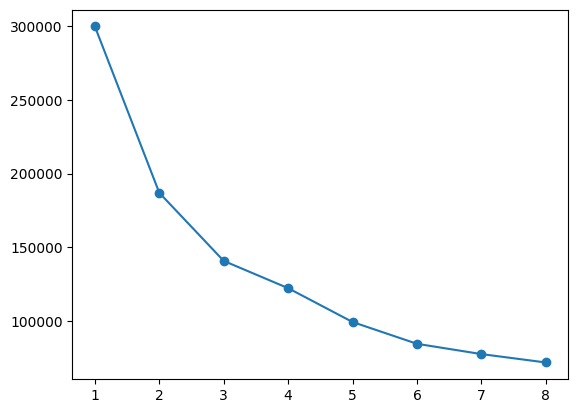

In [25]:
plt.plot(range(1,9),lst_in,marker='o');

In [26]:
minmax = MinMaxScaler()

In [27]:
minmax.fit(X)

MinMaxScaler()

In [28]:
Xmm = pd.DataFrame(minmax.transform(X), columns=X.columns)

In [29]:
lst = []
for k in range(1,9):
    km = KMeans(n_clusters=k)
    km.fit(Xmm)
    lst.append(km.inertia_)

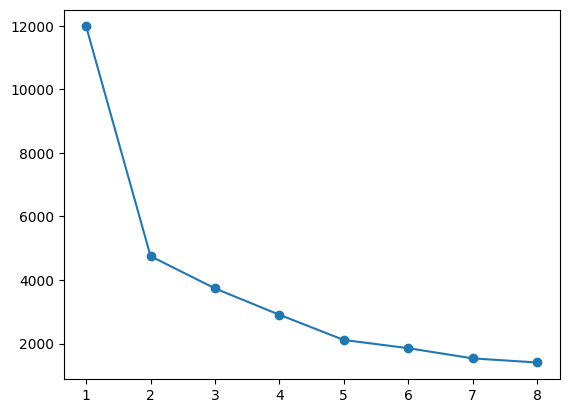

In [30]:
plt.plot(range(1,9),lst,marker='o');

In [31]:
cl_xp = GaussianMixture(n_components=3, max_iter=2000)
#cl_xt = GaussianMixture(n_components=3, max_iter=2000)

In [32]:
cl_xp.fit(Xp)
#cl_xt.fit(Xt)

GaussianMixture(max_iter=2000, n_components=3)

In [33]:
Xp["cl"] = cl_xp.predict(Xp)
#Xt["cl"] = cl_xt.predict(Xt)

In [36]:
pip install nbformat


   ---------------------------------------- 0.0/78.5 kB ? eta -:--:--
   -------------------- ------------------- 41.0/78.5 kB 991.0 kB/s eta 0:00:01
   ---------------------------------------- 78.5/78.5 kB 1.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/88.5 kB ? eta -:--:--
   ---------------------------------------- 88.5/88.5 kB ? eta 0:00:00
   ---------------------------------------- 0.0/63.8 kB ? eta -:--:--
   ---------------------------------------- 63.8/63.8 kB 3.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/235.5 kB ? eta -:--:--
   ---------------------------------------- 235.5/235.5 kB 7.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/45.8 kB ? eta -:--:--
   ---------------------------------------- 45.8/45.8 kB ? eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import cufflinks as cf
cf.go_offline()
import plotly.express as px
fig = px.scatter_3d(Xp, x='p1', y='p2', z='p3',
              color='cl')
fig.show()

In [ ]:
import cufflinks as cf
cf.go_offline()
import plotly.express as px
fig = px.scatter_3d(Xp, x='p1', y='p2', z='p3',
              color='cl')
fig.show()

In [39]:
print("PCA")
Xp.cl.value_counts(True)

PCA


cl
0    0.49312
1    0.30440
2    0.20248
Name: proportion, dtype: float64

In [67]:

n_clusters = 4



# Aglomerativo


In [ ]:
agglo = AgglomerativeClustering(n_clusters=n_clusters)
labels_agglo = agglo.fit_predict(Xs)



# K-Means


In [ ]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels_kmeans = kmeans.fit_predict(Xs)



# Gaussian Mixture


In [ ]:
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
labels_gmm = gmm.fit_predict(Xs)


In [59]:

# Añadir etiquetas al DataFrame para análisis posterior
# Xs['cluster_agglo'] = labels_agglo
Xs['cluster_kmeans'] = labels_kmeans
Xs['cluster_gmm'] = labels_gmm


In [61]:
pip install plotly.express

   ---------------------------------------- 0.0/232.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/232.9 kB ? eta -:--:--
   --------------- ------------------------ 92.2/232.9 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 232.9/232.9 kB 2.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB 8.3 MB/s eta 0:00:02
   --- ------------------------------------ 0.8/9.8 MB 13.0 MB/s eta 0:00:01
   ------- -------------------------------- 2.0/9.8 MB 17.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.5/9.8 MB 15.7 MB/s eta 0:00:01
   --------------- ------------------------ 3.8/9.8 MB 18.7 MB/s eta 0:00:01
   -------------------- ------------------- 5.1/9.8 MB 20.3 MB/s eta 0:00:01
   ------------------------- -------------- 6.2/9.8 MB 20.8 MB/s eta 0:00:01
   ------------------------------ --------- 7.5/9.8 MB 23.0 MB/s eta 0:00:01
   -----------


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import plotly.express as px

Xp['cl'] = labels_kmeans  

fig = px.scatter_3d(Xp, x='p1', y='p2', z='p3', color='cl',
                    title='Clusters con K-Means (PCA)',
                    labels={'cl': 'Cluster'})
fig.show()


# Perfilamiento

In [40]:
pip install pandas-profiling


     ---------------------------------------- 0.0/66.6 kB ? eta -:--:--
     ------------------ --------------------- 30.7/66.6 kB 1.4 MB/s eta 0:00:01
     ---------------------------------------- 66.6/66.6 kB 1.2 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     ---------------------------------------- 57.7/57.7 kB 3.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/262.6 kB ? eta -:--:--
   -------------------- ------------------- 133.1/262.6 kB 4.0 MB/s eta 0:00:01
   -------------------------------------- - 256.0/262.6 kB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 262.6/262.6

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-learn 1.6.1 requires joblib>=1.2.0, but you have joblib 1.1.1 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#len(df_credit), len(Xp), len(X)

In [ ]:
#perfil = pd.concat([X,df_credit[vard], Xp], axis=1)

In [ ]:
#perfil.groupby("cl").mean()

In [ ]:
#perfil.mean().to_frame().T

In [45]:

# Mostrar dimensiones del DataFrame
print("📐 Dimensiones del DataFrame:")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")


📐 Dimensiones del DataFrame:
Filas: 100000, Columnas: 13



In [46]:

# Tipos de datos
print("📋 Tipos de datos:")
print(df.dtypes, "\n")


📋 Tipos de datos:
Genero_Usuario           float64
Edad_Usuario             float64
Bici                       int64
Ciclo_Estacion_Retiro    float64
Fecha_Retiro               int32
Hora_Retiro              float64
Ciclo_Estacion_Arribo    float64
Fecha_Arribo               int32
Hora_Arribo              float64
Unnamed: 9               float64
Unnamed: 10              float64
Unnamed: 11              float64
Ciclo_EstacionArribo     float64
dtype: object 



In [47]:

# Recuento de valores nulos
print("🧼 Valores nulos por columna:")
print(df.isnull().sum(), "\n")


🧼 Valores nulos por columna:
Genero_Usuario                0
Edad_Usuario                  0
Bici                          0
Ciclo_Estacion_Retiro         0
Fecha_Retiro                  0
Hora_Retiro                   0
Ciclo_Estacion_Arribo         0
Fecha_Arribo                  0
Hora_Arribo                   0
Unnamed: 9               100000
Unnamed: 10              100000
Unnamed: 11              100000
Ciclo_EstacionArribo     100000
dtype: int64 



In [62]:

# Cantidad de valores únicos por columna
print("Valores únicos por columna:")
print(df.nunique(), "\n")


Valores únicos por columna:
Genero_Usuario              2
Edad_Usuario               62
Bici                     1193
Ciclo_Estacion_Retiro      85
Fecha_Retiro               93
Hora_Retiro              1063
Ciclo_Estacion_Arribo      87
Fecha_Arribo               92
Hora_Arribo              1172
Unnamed: 9                  0
Unnamed: 10                 0
Unnamed: 11                 0
Ciclo_EstacionArribo        0
dtype: int64 



In [63]:

# Estadísticas descriptivas
print("Estadísticas generales (solo numéricas):")
print(df.describe().T, "\n")


Estadísticas generales (solo numéricas):
                          count         mean           std   min         25%  \
Genero_Usuario         100000.0     0.740520      0.438352   0.0    0.000000   
Edad_Usuario           100000.0    35.356830     10.268543  17.0   28.000000   
Bici                   100000.0  1441.109350  28835.763724   1.0  300.000000   
Ciclo_Estacion_Retiro  100000.0    43.534140     25.548651   1.0   20.000000   
Fecha_Retiro           100000.0   108.328330     20.371210  45.0   95.000000   
Hora_Retiro            100000.0    15.292926      4.416843   0.0   11.766667   
Ciclo_Estacion_Arribo  100000.0    43.745840     26.297196   1.0   20.000000   
Fecha_Arribo           100000.0   108.332620     20.368543  47.0   95.000000   
Hora_Arribo            100000.0    15.458232      4.465440   0.0   11.983333   
Unnamed: 9                  0.0          NaN           NaN   NaN         NaN   
Unnamed: 10                 0.0          NaN           NaN   NaN         NaN   

In [65]:

# Detectar posibles outliers con el método del IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print("Posibles outliers por columna numérica:")
print(outliers[outliers > 0], "\n")


Posibles outliers por columna numérica:
Edad_Usuario             1862
Bici                       85
Fecha_Retiro               67
Hora_Retiro               479
Ciclo_Estacion_Arribo       4
Fecha_Arribo               65
Hora_Arribo               619
dtype: int64 



C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\2319406302.py:5: UserWarning:

Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.

C:\Users\pablo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.



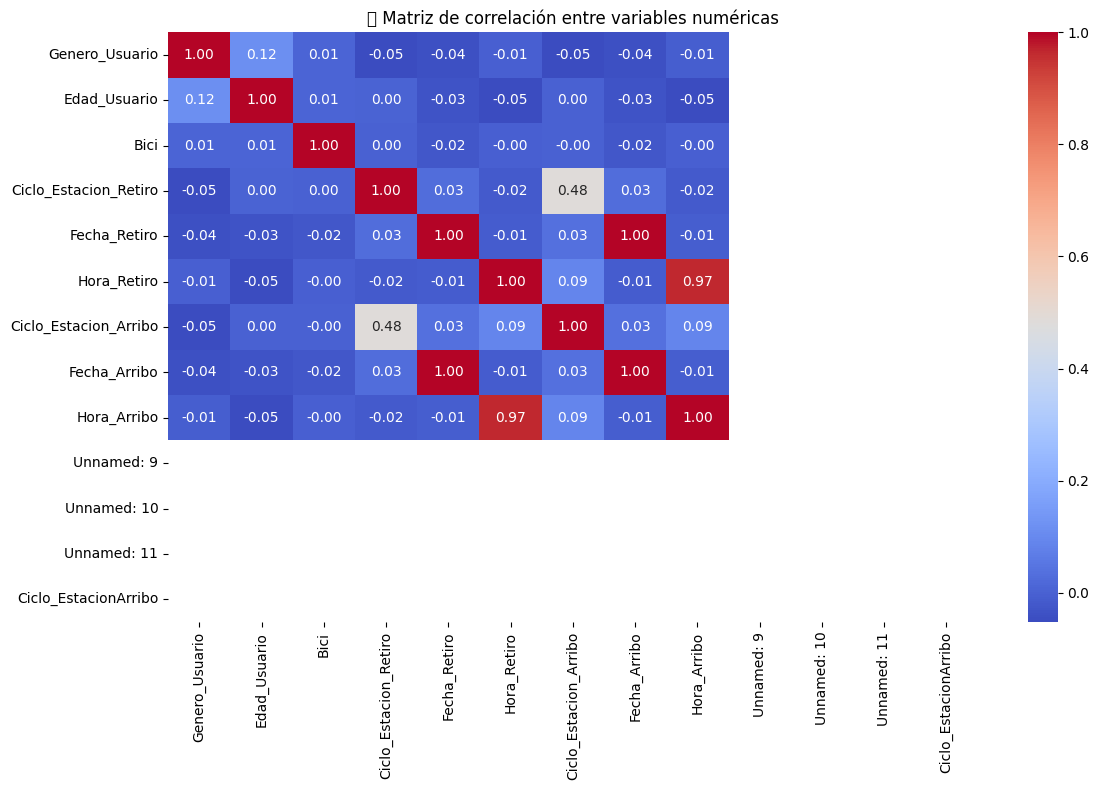

In [51]:

# Matriz de correlación
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("🔗 Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()


C:\Users\pablo\AppData\Local\Temp\ipykernel_11000\3132386025.py:4: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.

C:\Users\pablo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.



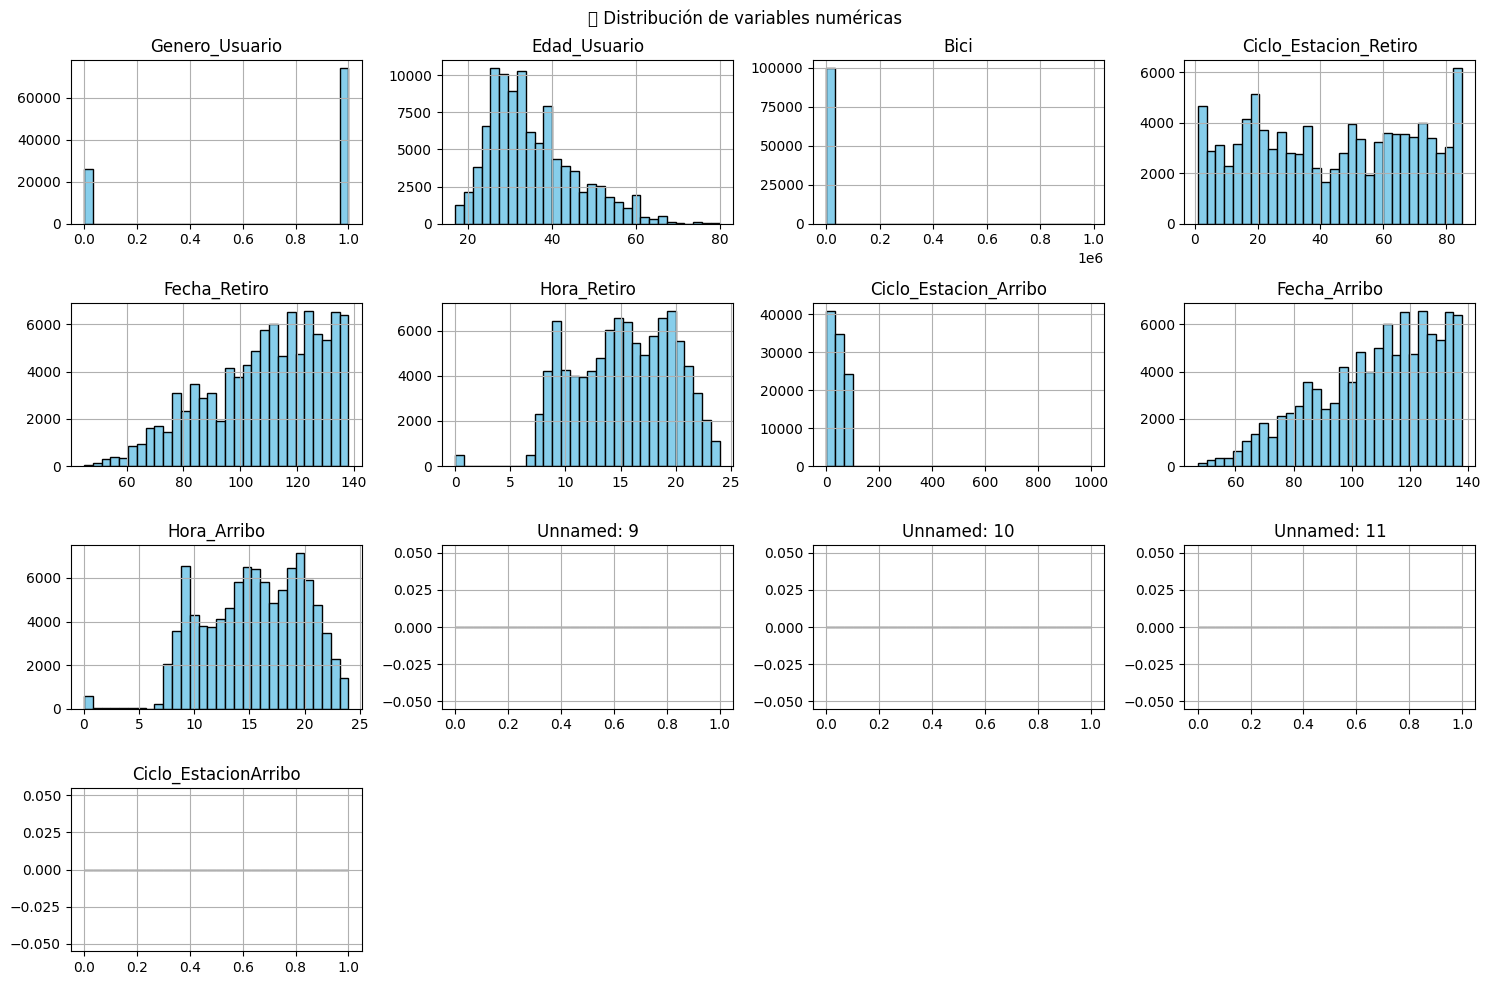

In [ ]:

# Histograma de variables numéricas
df.select_dtypes(include=[np.number]).hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.show()
